In [17]:
%pip install lightgbm

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 8.7 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    log_loss, 
    accuracy_score,
    classification_report,
    confusion_matrix
)
from lightgbm import LGBMClassifier

In [19]:
#Loading the dataset and checking its data types and missing values
df = pd.read_csv("train.csv")
print("--DF HEAD --")
print(df.head())
print("--DF INFO --")
print(df.info())

--DF HEAD --
   id   age  daily_screen_time_hours  social_media_hours  gaming_hours  \
0   0  24.0                      NaN                1.83          1.59   
1   1  19.0                     5.97                1.08           NaN   
2   2  18.0                     5.09                 NaN           NaN   
3   3  21.0                     6.42                1.26          1.42   
4   4  26.0                    11.20                1.87          2.81   

   work_study_hours  sleep_hours  notifications_per_day  app_opens_per_day  \
0              2.11         7.46                  122.0               38.0   
1              3.03         8.22                   76.0               19.0   
2               NaN         6.25                  134.0               60.0   
3              3.36         8.85                  112.0               94.0   
4              1.95         5.25                    NaN                NaN   

   weekend_screen_time  gender stress_level academic_work_impact  \
0    

In [ ]:
# Dealing with missing values. There are columns with lots of missing values, so I won't drop those columns, but instead I will fill them using the most appropriate
# method. 
# Step 1 - Check correlation between columns to see if the errors are random or not.
na_df = df.isna()
na_df['addicted_label'] = df["addicted_label"]
print("--NA CORRELATION WITH ADDICTED LABEL --")
print(na_df.corr()['addicted_label'].abs() > 0.05)
# Since there is no correlation between missing values and the addicted label, I can proceed filling the missing values using the most appropriate method. 

--NA CORRELATION WITH ADDICTED LABEL --
id                         False
age                        False
daily_screen_time_hours    False
social_media_hours         False
gaming_hours               False
work_study_hours           False
sleep_hours                False
notifications_per_day      False
app_opens_per_day          False
weekend_screen_time        False
gender                     False
stress_level               False
academic_work_impact       False
addicted_label              True
Name: addicted_label, dtype: bool


In [20]:
# Dealing with categorical variables. 
df['gender'] = df['gender'].astype('category')
df['stress_level'] = df['stress_level'].map({'Low': 0, 'Medium': 1, 'High': 2})
df['academic_work_impact'] = df['academic_work_impact'].map({'No': 0, 'Yes': 1})
print("--DF INFO AFTER CATEGORICAL CONVERSION --")
print(df.info())

--DF INFO AFTER CATEGORICAL CONVERSION --
<class 'pandas.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   id                       691369 non-null  int64   
 1   age                      662440 non-null  float64 
 2   daily_screen_time_hours  595515 non-null  float64 
 3   social_media_hours       557374 non-null  float64 
 4   gaming_hours             564548 non-null  float64 
 5   work_study_hours         639851 non-null  float64 
 6   sleep_hours              646889 non-null  float64 
 7   notifications_per_day    623785 non-null  float64 
 8   app_opens_per_day        610659 non-null  float64 
 9   weekend_screen_time      579306 non-null  float64 
 10  gender                   662335 non-null  category
 11  stress_level             636221 non-null  float64 
 12  academic_work_impact     647145 non-null  float64 
 13  addicted_labe

In [21]:
#Splitting the dataset into training and and test sets.
# For X we'll remove both the target label and the id column. The id column is just an arbitray identifier and it has no relationship with the smartphone addiction.
X = df.drop(columns=["addicted_label", "id"])
y = df["addicted_label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.42, random_state=42, stratify=y)

In [22]:
 # Building the LightGBM model.
 model = LGBMClassifier(random_state=42)
 model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 284475, number of negative: 116519
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020716 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1958
[LightGBM] [Info] Number of data points in the train set: 400994, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.709425 -> initscore=0.892591
[LightGBM] [Info] Start training from score 0.892591


,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


Accuracy Score: 0.8888

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.80      0.81     84376
           1       0.92      0.93      0.92    205999

    accuracy                           0.89    290375
   macro avg       0.87      0.86      0.86    290375
weighted avg       0.89      0.89      0.89    290375



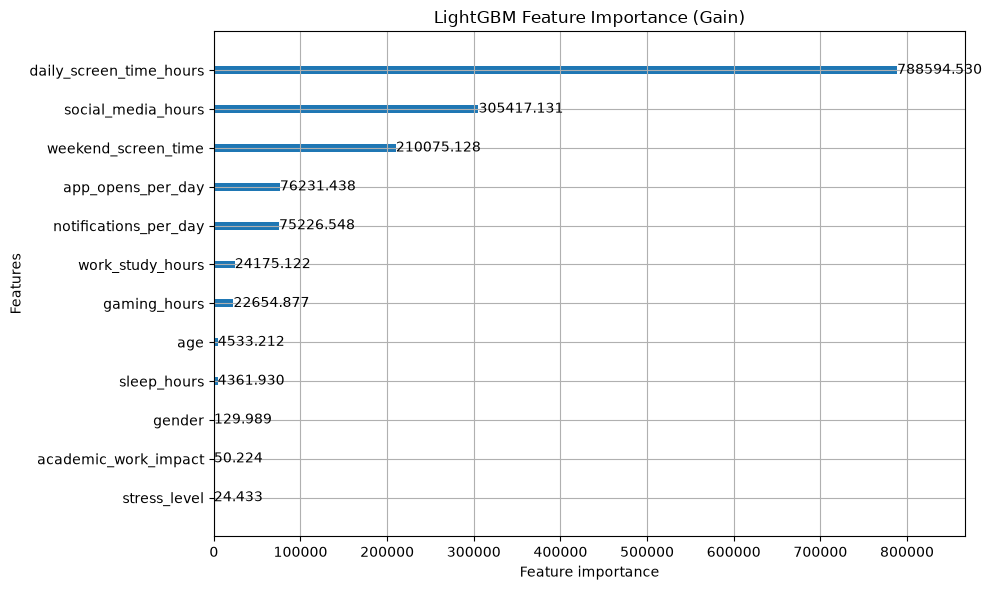

In [24]:
# Let's generate prediction on the test set and inspect the accuracy score, confusion matrix and feature importance
y_pred = model.predict(X_test)

print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

import lightgbm as lgb

lgb.plot_importance(model, importance_type='gain', figsize=(10,6), max_num_features=15)
plt.title("LightGBM Feature Importance (Gain)")
plt.tight_layout()
plt.show()

In [25]:
# Let's create a function to do some feature engineering to see if we can improve the model's performance.
def create_features(data):
    df_feat = data.copy()
    eps = 1e-5
    
    # 1. Ratios and proportions
    df_feat['social_share'] = df_feat['social_media_hours'] / (df_feat['daily_screen_time_hours'] + eps)
    df_feat['gaming_share'] = df_feat['gaming_hours'] / (df_feat['daily_screen_time_hours'] + eps)
    df_feat['screen_to_awake_ratio'] = df_feat['daily_screen_time_hours'] / (24 - df_feat['sleep_hours'] + eps)
    
    # 2. Behavioral differences
    df_feat['weekend_diff'] = df_feat['weekend_screen_time'] - df_feat['daily_screen_time_hours']
    df_feat['other_screen_time'] = df_feat['daily_screen_time_hours'] - (
        df_feat['social_media_hours'] + df_feat['gaming_hours'] + df_feat['work_study_hours']
    )
    
    # 3. Usage intensity
    df_feat['notif_per_open'] = df_feat['notifications_per_day'] / (df_feat['app_opens_per_day'] + eps)
    df_feat['mins_per_open'] = (df_feat['daily_screen_time_hours'] * 60) / (df_feat['app_opens_per_day'] + eps)
    
    return df_feat

# Apply the feature engineering function to the dataset
df_enhanced = create_features(df)

[LightGBM] [Info] Number of positive: 392379, number of negative: 160716
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.126836 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3742
[LightGBM] [Info] Number of data points in the train set: 553095, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.709424 -> initscore=0.892589
[LightGBM] [Info] Start training from score 0.892589
New Accuracy Score: 0.8901

New Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.79      0.81     40179
           1       0.92      0.93      0.92     98095

    accuracy                           0.89    138274
   macro avg       0.87      0.86      0.87    138274
weighted avg       0.89      0.89      0.89    138274



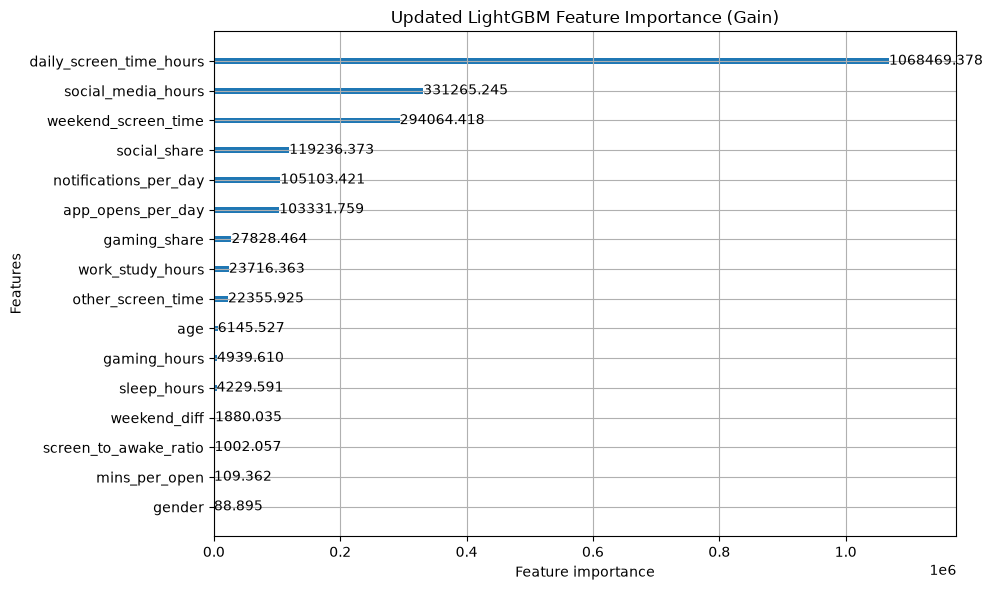

In [26]:
#Recreating the train/test splt sugin the enhanced dataset, fitting the model and evaluating its performance
X = df_enhanced.drop(columns=['addicted_label', 'id'], errors = 'ignore')
y = df_enhanced['addicted_label']

X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model1 = LGBMClassifier(random_state=42)
model1.fit(X_train1, y_train1)

y_pred1 = model1.predict(X_test1)
print(f"New Accuracy Score: {accuracy_score(y_test1, y_pred1):.4f}\n")
print("New Classification Report:")
print(classification_report(y_test1, y_pred1))

lgb.plot_importance(model1, importance_type='gain', figsize=(10,6), max_num_features=20)
plt.title("Updated LightGBM Feature Importance (Gain)")
plt.tight_layout()
plt.show()